#  Exploratory Data Analysis (EDA) & Data Cleaning

This project performs data cleaning and exploratory data analysis on the Adult 
Income Dataset to understand patterns, handle missing values, and improve data quality.

##  Problem Statement

The goal of this project is to analyze demographic and employment-related factors influencing income levels and prepare the dataset for further predictive modeling.

In [1]:
# LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MINI PROJECT ON EDA + DATA CLEANING

##  Dataset Description

This project uses the Adult Income Dataset, also known as the Census Income Dataset.

 - Source: U.S. Census data  
 - Objective: Predict whether an individual's income exceeds $50K per year
 - Type: Structured tabular dataset
 - Common use: Classification and data analysis tasks

This dataset contains demographic and employment-related attributes such as age, workclass, education, occupation, and income.

##  About adult.data File

The `adult.data` file is the main dataset used in this project.

- It contains raw data without column headers
- Each row represents one individual
- Data is comma-separated
- Missing values are represented as " ?"

This file is used for performing data cleaning, preprocessing, and exploratory data analysis.

In [2]:
df = pd.read_csv("adult.data")
df.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [3]:
# Handling Data Inconsistency
cols = ['age', 'workclass','fnlwgt','education','education-num','marital-status','occupation',
        'relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country','income']
df = pd.read_csv('adult.data',names = cols) # assigning names while uploading
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## Data Loading

The dataset does not contain column headers.  
Therefore, column names were manually assigned during loading for better readability and analysis.

## Understanding the Dataset

In this step, we explore the structure and basic information of the dataset.

In [4]:
df.shape

(32561, 15)

In [5]:
df.head(10) # top 10

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [6]:
df.tail(10) # bottom 20

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [7]:
df.sample(5) # random 5 records .. if i dont mention no if pick 1 random record

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
18906,43,State-gov,506329,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,15024,0,40,?,>50K
24172,77,Private,154205,HS-grad,9,Widowed,Adm-clerical,Not-in-family,White,Female,0,0,10,United-States,<=50K
25842,37,Private,146398,Bachelors,13,Never-married,Prof-specialty,Not-in-family,Black,Female,0,0,40,United-States,<=50K
28908,46,Private,176552,11th,7,Divorced,Prof-specialty,Unmarried,Amer-Indian-Eskimo,Male,0,0,40,United-States,>50K
30308,35,Private,216256,Assoc-voc,11,Never-married,Other-service,Not-in-family,White,Male,0,0,60,United-States,<=50K


In [8]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [10]:
# prints only the numerical column names
df.select_dtypes(include = 'int64').columns

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [11]:
# prints only the object/string column names
df.select_dtypes(include = 'object').columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [12]:
df.describe()# shows for only numerical 

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [13]:
df.describe(include = 'object') # includes string 

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [14]:
for col in df.select_dtypes(include='object').columns:
    print("\nColumn:", col)
    print("Unique values:", df[col].nunique()) #unique


Column: workclass
Unique values: 9

Column: education
Unique values: 16

Column: marital-status
Unique values: 7

Column: occupation
Unique values: 15

Column: relationship
Unique values: 6

Column: race
Unique values: 5

Column: sex
Unique values: 2

Column: native-country
Unique values: 42

Column: income
Unique values: 2


## Data Cleaning

The dataset contains missing values represented in a non-standard format such as " ?".

Steps performed:

 1. Identified inconsistent values and extra spaces in categorical columns  
 2. Removed leading and trailing spaces using string operations  
 3. Replaced " ?" with proper missing values (NaN or meaningful category)  
 4. Standardized categorical data for accurate analysis  

This step ensures data quality and consistency before performing further analysis.

##  Data Cleaning

In this step, we identify inconsistencies, analyze missing values, and clean the dataset to improve data quality.

### Handling Data Inconsistency

In [15]:
# remove extra spaces from categorical columns
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

### Missing Value Analysis

In [16]:
# check missing values represented as '?'
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].isin(['?']).sum())

workclass 1836
education 0
marital-status 0
occupation 1843
relationship 0
race 0
sex 0
native-country 583
income 0


In [17]:
# convert '?' to NaN
df[['workclass','occupation','native-country']] = df[['workclass','occupation','native-country']].replace('?', np.nan)

In [18]:
# check percentage of missing values
(df.isnull().mean() * 100).round(2)

age               0.00
workclass         5.64
fnlwgt            0.00
education         0.00
education-num     0.00
marital-status    0.00
occupation        5.66
relationship      0.00
race              0.00
sex               0.00
capital-gain      0.00
capital-loss      0.00
hours-per-week    0.00
native-country    1.79
income            0.00
dtype: float64

### Handling Missing Values

In [19]:
# fill missing values using mode (categorical columns)
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])
df['native-country'] = df['native-country'].fillna(df['native-country'].mode()[0])

In [20]:
df[['workclass','occupation','native-country']].isnull().sum()

workclass         0
occupation        0
native-country    0
dtype: int64

### Duplicate Analysis

In [21]:
# check duplicates
print(df.duplicated().sum())

24


In [47]:
# remove duplicates
df = df.drop_duplicates()

In [48]:
# verify
print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


##  Exploratory Data Analysis

### Univariate Analysis
Analyze one variable at a time

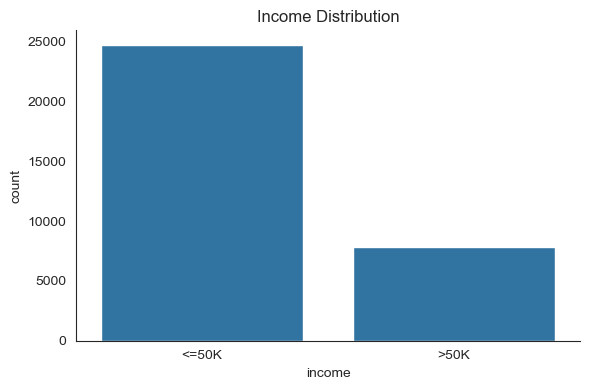

In [24]:
# income distribution

df['income'].value_counts()
sns.set_style("white")

# Income
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
sns.despine()
plt.tight_layout()
plt.show()

The dataset is highly imbalanced, with a majority of individuals earning ≤50K compared to those earning >50K.

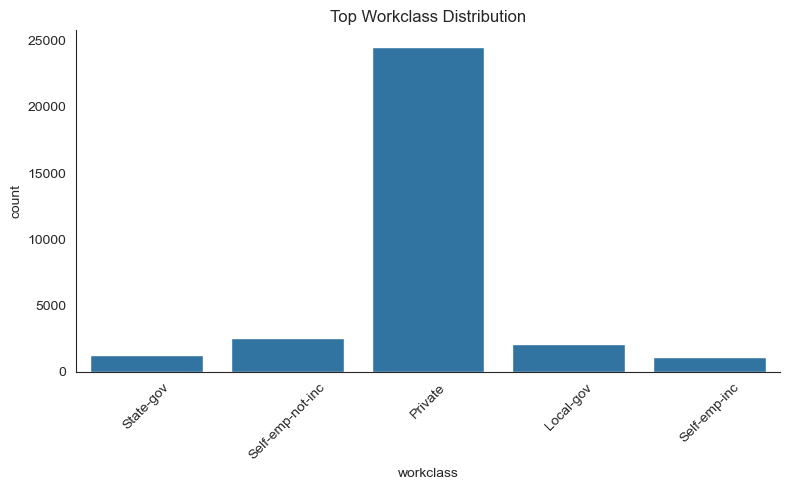

In [25]:
# Workclass (top categories only)
plt.figure(figsize=(8,5))
top_workclass = df['workclass'].value_counts().index[:5]
sns.countplot(x='workclass', data=df[df['workclass'].isin(top_workclass)])
plt.title("Top Workclass Distribution")
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

The dataset shows that most individuals belong to the Private workclass category.

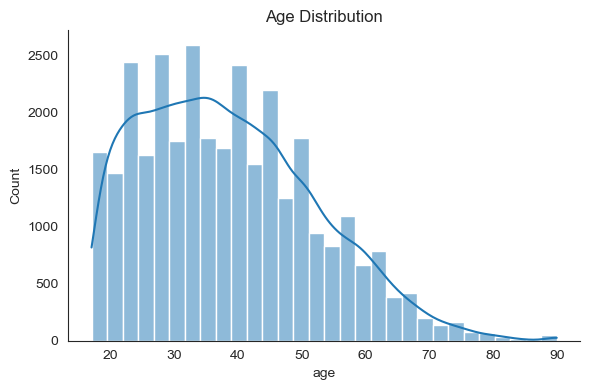

In [26]:
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
sns.despine()
plt.tight_layout()
plt.show()

The age distribution is slightly right-skewed, with most individuals concentrated between 25 and 50 years.

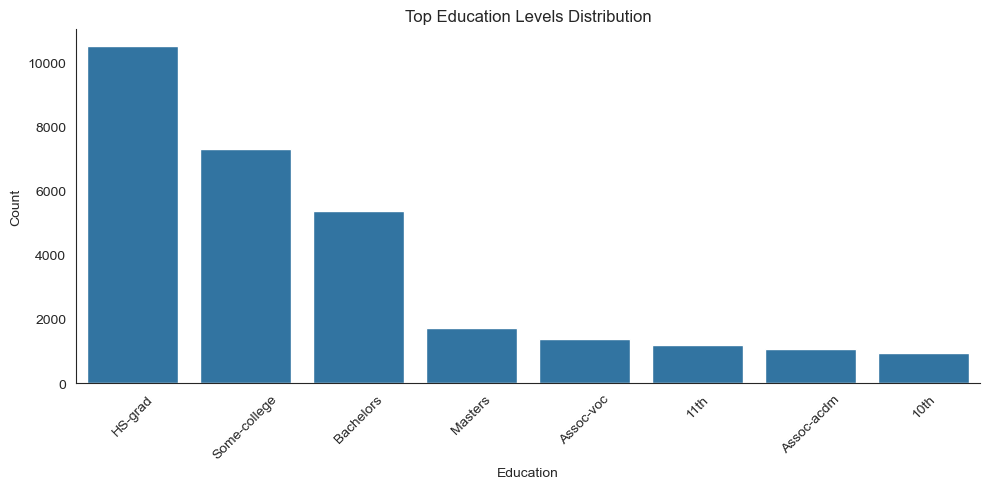

In [27]:
# Education distribution (top categories only)
plt.figure(figsize=(10,5))

top_edu = df['education'].value_counts().index[:8]

sns.countplot(
    x='education',
    data=df[df['education'].isin(top_edu)],
    order=top_edu
)

plt.title("Top Education Levels Distribution")
plt.xlabel("Education")
plt.ylabel("Count")

plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()

plt.show()

The distribution shows that most individuals fall under mid-level education categories such as HS-grad and Some-college, indicating a concentration in these groups.

### Bivariate Analysis
Relationship between variables

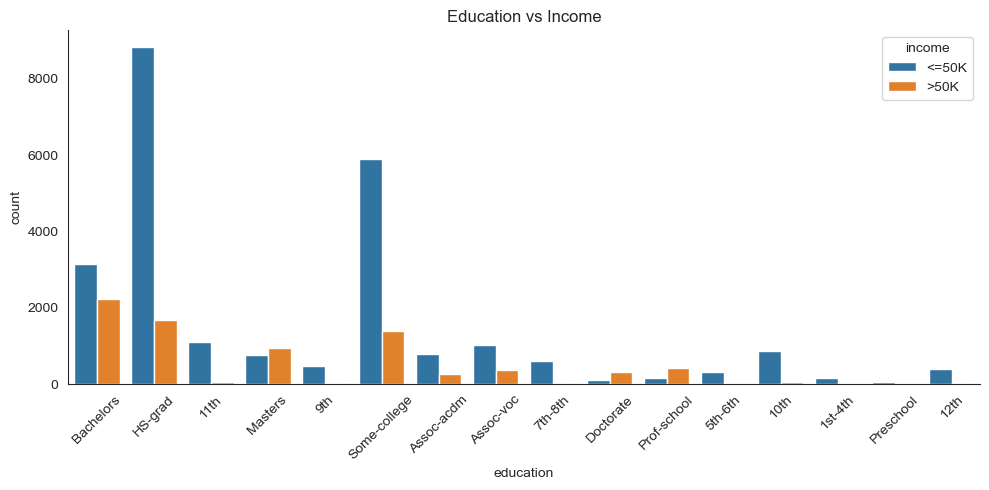

In [28]:
# Education vs Income
plt.figure(figsize=(10,5))
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45)
plt.title("Education vs Income")
sns.despine()
plt.tight_layout()
plt.show()

Individuals with higher education levels such as Bachelors and Masters show a significantly higher proportion of income >50K compared to lower education levels.

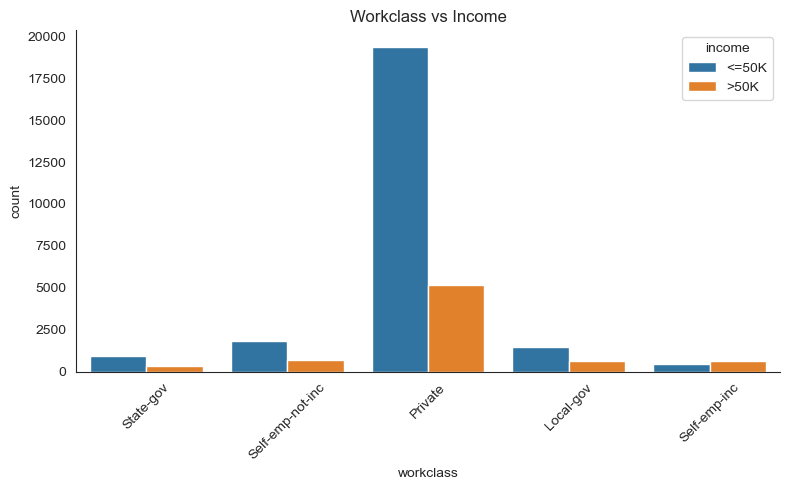

In [29]:
# Workclass vs Income (top categories)
plt.figure(figsize=(8,5))
sns.countplot(x='workclass', hue='income',
              data=df[df['workclass'].isin(top_workclass)])
plt.xticks(rotation=45)
plt.title("Workclass vs Income")
sns.despine()
plt.tight_layout()
plt.show()

Private sector employees dominate both income groups, but higher-paying jobs are relatively more common in government and self-employed categories.

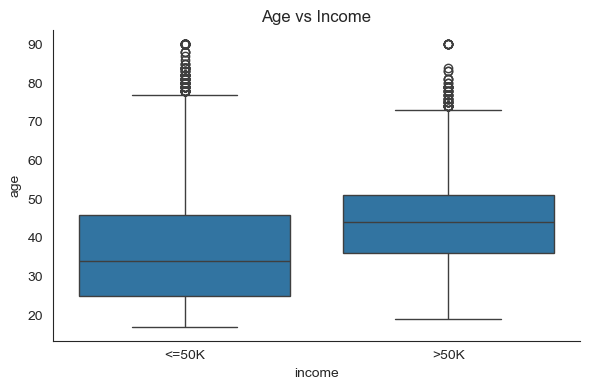

In [30]:
# Age vs Income
plt.figure(figsize=(6,4))
sns.boxplot(x='income', y='age', data=df)
plt.title("Age vs Income")
sns.despine()
plt.tight_layout()
plt.show()

Individuals earning >50K tend to be older on average, suggesting that income increases with experience and age.

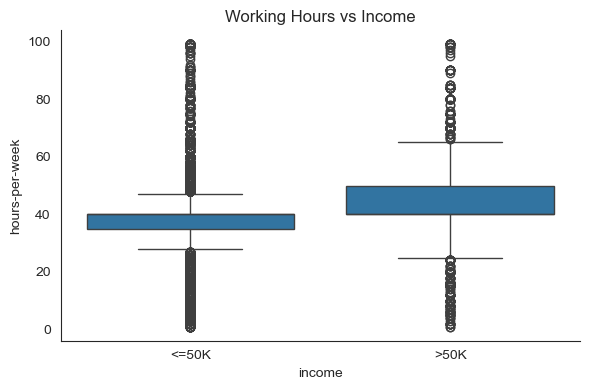

In [31]:
# Hours per week vs Income
plt.figure(figsize=(6,4))
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title("Working Hours vs Income")
sns.despine()
plt.tight_layout()
plt.show()

Higher income individuals tend to work more hours per week, indicating a positive relationship between working hours and income.

###  Filtering & Subset Analysis

In [32]:
# age-based filtering
df[df.age < 20]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
26,19,Private,168294,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,0,0,40,United-States,<=50K
37,19,Private,544091,HS-grad,9,Married-AF-spouse,Adm-clerical,Wife,White,Female,0,0,25,United-States,<=50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,United-States,<=50K
70,19,Private,101509,Some-college,10,Never-married,Prof-specialty,Own-child,White,Male,0,0,32,United-States,<=50K
78,18,Private,309634,11th,7,Never-married,Other-service,Own-child,White,Female,0,0,22,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32392,18,Private,200047,12th,8,Never-married,Adm-clerical,Own-child,White,Male,0,0,35,United-States,<=50K
32437,19,Private,60890,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,49,United-States,<=50K
32443,18,Private,41381,HS-grad,9,Never-married,Sales,Own-child,White,Female,0,1602,20,United-States,<=50K
32447,17,Private,117798,10th,6,Never-married,Other-service,Own-child,White,Male,0,0,20,United-States,<=50K


In [33]:
df[(df.age < 20) | (df.age > 70)]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
26,19,Private,168294,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,0,0,40,United-States,<=50K
37,19,Private,544091,HS-grad,9,Married-AF-spouse,Adm-clerical,Wife,White,Female,0,0,25,United-States,<=50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,United-States,<=50K
70,19,Private,101509,Some-college,10,Never-married,Prof-specialty,Own-child,White,Male,0,0,32,United-States,<=50K
74,79,Private,124744,Some-college,10,Married-civ-spouse,Prof-specialty,Other-relative,White,Male,0,0,20,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32496,18,Private,436163,11th,7,Never-married,Prof-specialty,Own-child,White,Male,0,0,20,United-States,<=50K
32501,71,Private,138145,9th,5,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,United-States,<=50K
32525,81,Private,120478,Assoc-voc,11,Divorced,Prof-specialty,Unmarried,White,Female,0,0,1,United-States,<=50K
32539,71,Private,287372,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,10,United-States,>50K


In [34]:
# income for age > 25
df[df.age > 25]['income'].value_counts()

income
<=50K    18423
>50K      7727
Name: count, dtype: int64

Younger individuals (below 20) are less represented in higher income groups, likely due to limited work experience.

###  Statistical Analysis

In [35]:
# averages
df.groupby('income')['age'].mean()

income
<=50K    36.783738
>50K     44.249841
Name: age, dtype: float64

In [36]:
df.groupby('income')['hours-per-week'].mean()

income
<=50K    38.840210
>50K     45.473026
Name: hours-per-week, dtype: float64

In [37]:
# overall stats
print(df['hours-per-week'].mean())

40.437455852092995


In [38]:
print(df['hours-per-week'].median())

40.0


Higher income groups tend to have greater average age and working hours, reinforcing the importance of experience and effort.

###  Correlation Analysis

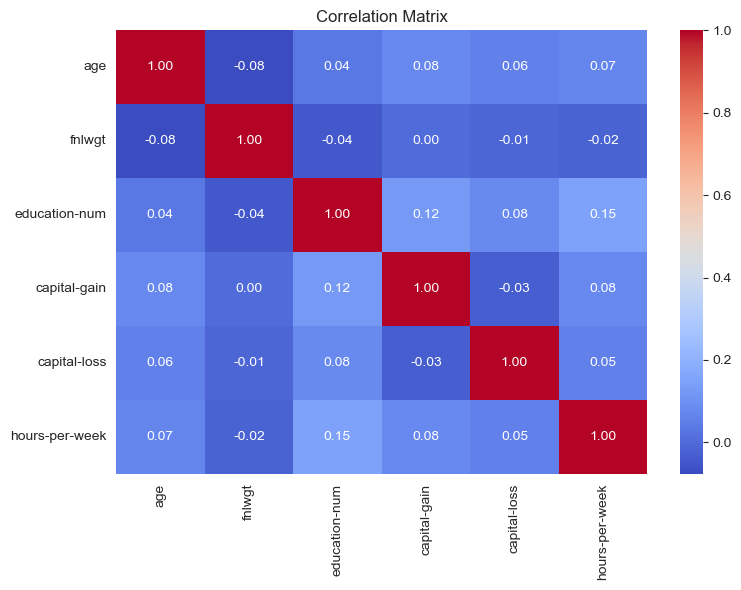

In [39]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Most numerical features show weak correlation with each other, indicating that income is influenced more by categorical factors than numerical ones.

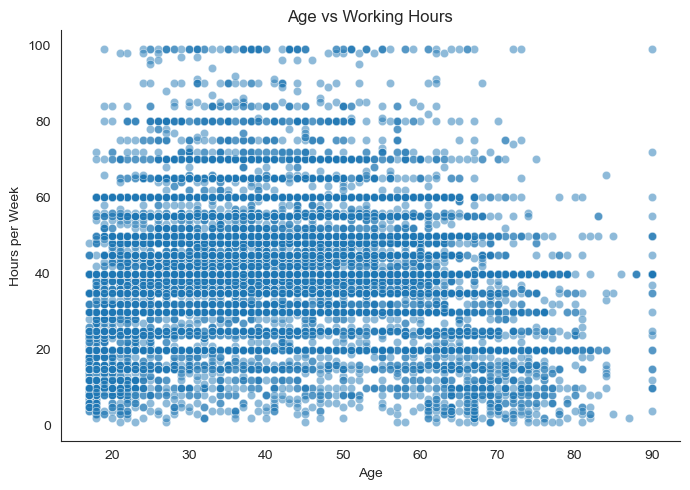

In [40]:
# relationship
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='age',
    y='hours-per-week',
    data=df,
    alpha=0.5   # makes points transparent → avoids clutter
)

plt.title("Age vs Working Hours")
plt.xlabel("Age")
plt.ylabel("Hours per Week")

sns.despine()
plt.tight_layout()

plt.show()

There is no strong linear relationship between age and working hours, although slight clustering suggests moderate working patterns across age groups.

###  Outlier Detection & Handling

In [41]:
# Select numerical columns
num_cols = df.select_dtypes(include='number').columns

# Detect outliers for each column
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nColumn: {col}")
    print(f"Outliers count: {len(outliers)}")


Column: age
Outliers count: 143

Column: fnlwgt
Outliers count: 992

Column: education-num
Outliers count: 1198

Column: capital-gain
Outliers count: 2712

Column: capital-loss
Outliers count: 1519

Column: hours-per-week
Outliers count: 9008


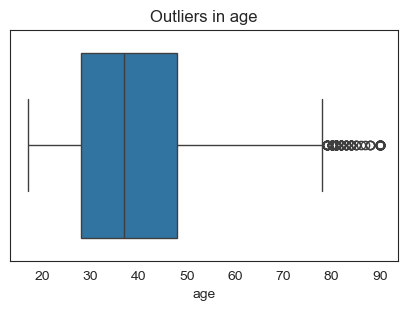

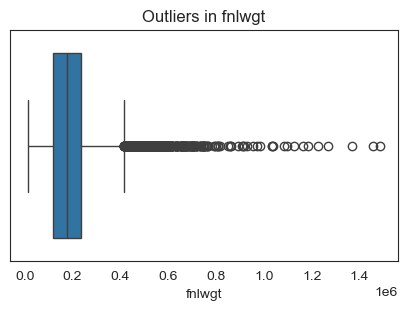

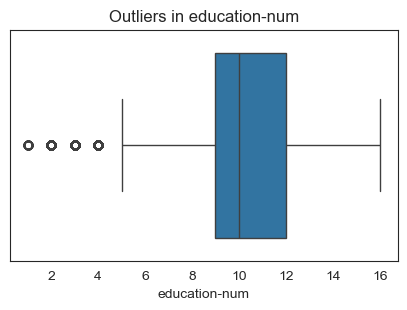

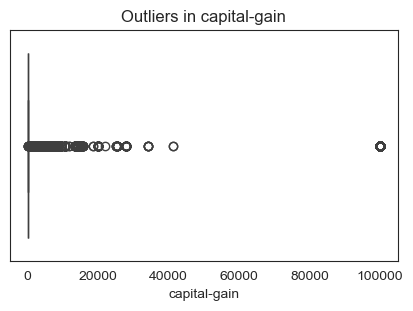

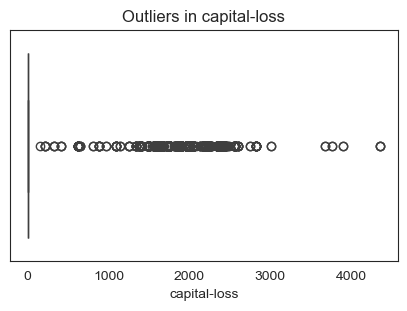

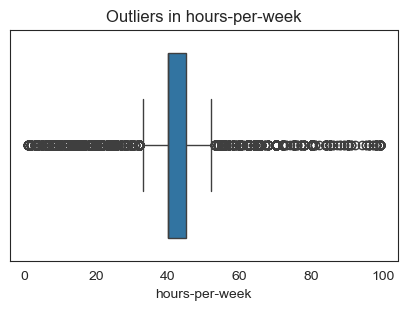

In [42]:
# before
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [43]:
# Handling Outliers 
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

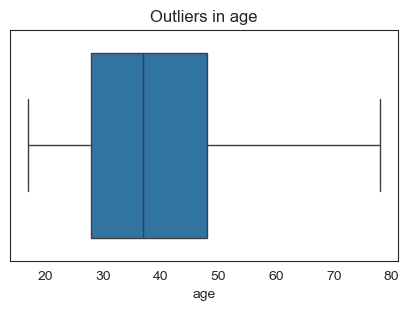

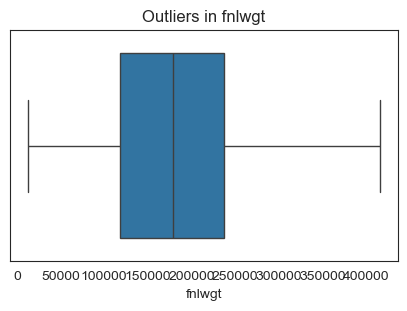

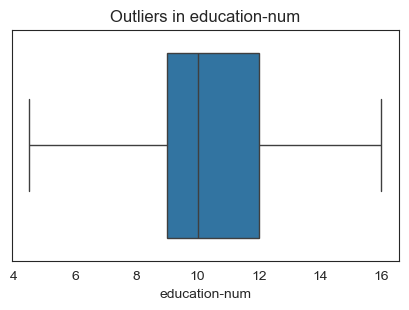

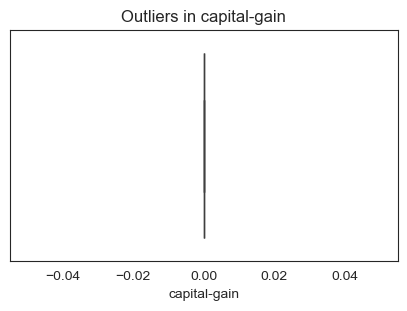

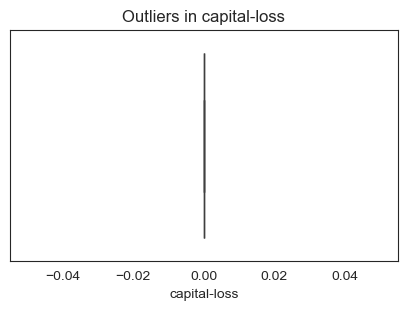

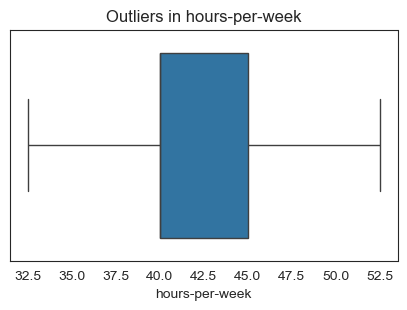

In [44]:
# after
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

Outliers were detected across numerical columns using the IQR method. 
Extreme values were handled using clipping to reduce their impact while preserving the dataset size and overall distribution.

## Cleaned_Data

In [45]:
df.to_csv("cleaned_adult_data.csv", index=False)
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,32.5,United-States,<=50K
2,38,Private,215646,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53,Private,234721,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28,Private,338409,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12.0,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38.0,United-States,<=50K
32557,40,Private,154374,HS-grad,9.0,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40.0,United-States,>50K
32558,58,Private,151910,HS-grad,9.0,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40.0,United-States,<=50K
32559,22,Private,201490,HS-grad,9.0,Never-married,Adm-clerical,Own-child,White,Male,0,0,32.5,United-States,<=50K


In [49]:
# 1. Check missing values
print("Missing values:\n", df.isnull().sum())

# 2. Check '?' still exists
print("\nCheck '?' values:")
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].isin(['?']).sum())

# 3. Check duplicates
print("Duplicates:", df.duplicated().sum())

# 4. Check data types
print("\nData types:\n", df.dtypes)

# 5. Basic stats (sanity check)
print("\nSummary stats:\n", df.describe())

# 6. Shape (final dataset size)
print("\nDataset shape:", df.shape)

Missing values:
 age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Check '?' values:
workclass 0
education 0
marital-status 0
occupation 0
relationship 0
race 0
sex 0
native-country 0
income 0
Duplicates: 0

Data types:
 age                 int64
workclass          object
fnlwgt              int64
education          object
education-num     float64
marital-status     object
occupation         object
relationship       object
race               object
sex                object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income             object
dtype: object

Summary stats:
                 age         fnlwgt  education-num  capital-gain  capital-loss  \
count  32508.

##  Key Insights

- Income distribution is highly imbalanced, with a majority of individuals earning ≤50K compared to those earning >50K  
- Individuals with higher education levels such as Bachelors and Masters have a significantly higher likelihood of earning >50K  
- The Private workclass dominates the dataset, but higher income proportions are observed in government and self-employed roles  
- Age plays an important role, as individuals earning >50K tend to be older, indicating experience as a key factor  
- People working longer hours per week are more likely to belong to the higher income group  
- Numerical features show weak linear correlations, indicating that income is more strongly influenced by categorical     variables.
- Outliers were present in numerical columns and were handled using the IQR method to maintain realistic data distribution  

##  Business Understanding

This analysis provides insights into the key factors influencing income levels, such as education, workclass, age, and working hours.  

Organizations can use these findings to:
- Identify workforce patterns and income distribution trends  
- Understand the impact of education and experience on earning potential  
- Support data-driven decision-making in hiring, compensation, and workforce planning  

The cleaned and analyzed dataset can also be used as a foundation for building predictive models for income classification.

##  Conclusion

In this project, comprehensive data cleaning and exploratory data analysis were performed on the Adult Income Dataset.  

- Data inconsistencies and missing values were effectively handled  
- Outliers were identified and treated using the IQR method  
- Key patterns and relationships influencing income were uncovered  

The analysis highlights the importance of education, experience, and working hours in determining income levels.  
The dataset is now well-prepared for further advanced analysis and machine learning modeling.